<a href="https://colab.research.google.com/github/Oksi193/Analyst_Customer/blob/main/Analisis_RFM_Segmentasi_User_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis RFM Segmentasi User

## Impor Packages

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Impor Data

In [2]:
# Ganti 'nama_folder' dan 'nama_file.csv' sesuai dengan lokasi data Anda di Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/RFM dan Retention Analsyt/Online Retail Data.csv'

# Membaca data
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk memastikan data sudah masuk
df.head().style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.500000,12346.000000
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.250000,14590.000000
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.500000,12346.000000
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.850000,nan
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.750000,nan


In [3]:
# Informasi umum data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


## Data Preprocessing

In [4]:
df_clean = df.copy()

# 1. Mengkonversi kolom order_date menjadi datetime (Lebih aman dari astype)
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# 2. Membuat kolom year_month
df_clean['year_month'] = df_clean['order_date'].dt.to_period('M')

# 3. Menghapus semua baris tanpa customer_id
df_clean = df_clean[~df_clean['customer_id'].isna()]

# 4. Menghapus semua baris tanpa product_name
df_clean = df_clean[~df_clean['product_name'].isna()]

# 5. Membuat semua product_name berhuruf kecil
df_clean['product_name'] = df_clean['product_name'].str.lower()

# 6. Menghapus semua baris dengan product_code ATAU product_name test
# (Gunakan & agar data yang lolos adalah data yang bersih di code DAN bersih di name)
df_clean = df_clean[(~df_clean['product_code'].astype(str).str.lower().str.contains('test')) &
                    (~df_clean['product_name'].str.contains('test'))]

# 7. Membuat kolom order_status (Pastikan order_id di-cast ke string agar tidak error)
df_clean['order_status'] = np.where(df_clean['order_id'].astype(str).str[:1] == 'C', 'cancelled', 'delivered')

# 8. Mengubah nilai quantity yang negatif menjadi positif
df_clean['quantity'] = df_clean['quantity'].abs()

# 9. Menghapus baris dengan price bernilai negatif
df_clean = df_clean[df_clean['price'] > 0]

# 10. Membuat nilai amount
df_clean['amount'] = df_clean['quantity'] * df_clean['price']

# 11. Mengganti product_name dengan salah satu product_name-nya yang paling sering muncul
most_freq_product_name = df_clean.groupby(['product_code','product_name'], as_index=False).agg(order_cnt=('order_id','nunique')).sort_values(['product_code','order_cnt'], ascending=[True,False])
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])

df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}), how='left', on='product_code')
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')

# 12. Mengkonversi customer_id menjadi string (Ubah ke int dulu untuk membuang desimal .0 bawaan NaN)
df_clean['customer_id'] = df_clean['customer_id'].astype(int).astype(str)

# 13. Menghapus outlier
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']])) < 3).all(axis=1)]

# 14. Reset index
df_clean = df_clean.reset_index(drop=True)

# 15. Membuat kolom date
df_clean['date'] = df_clean['order_date'].dt.normalize()

df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,order_status,amount,date
0,C493411,21539,red retrospot butter dish,1,2010-01-04 09:43:00,4.25,14590,2010-01,cancelled,4.25,2010-01-04
1,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590,2010-01,delivered,91.80,2010-01-04
2,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590,2010-01,delivered,51.00,2010-01-04
3,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590,2010-01,delivered,5.10,2010-01-04
4,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590,2010-01,delivered,8.50,2010-01-04
...,...,...,...,...,...,...,...,...,...,...,...
358464,539988,84380,set of 3 butterfly cookie cutters,1,2010-12-23 16:06:00,1.25,18116,2010-12,delivered,1.25,2010-12-23
358465,539988,84849D,hot baths soap holder,1,2010-12-23 16:06:00,1.69,18116,2010-12,delivered,1.69,2010-12-23
358466,539988,84849B,fairy soap soap holder,1,2010-12-23 16:06:00,1.69,18116,2010-12,delivered,1.69,2010-12-23
358467,539988,22854,cream sweetheart egg holder,2,2010-12-23 16:06:00,4.95,18116,2010-12,delivered,9.90,2010-12-23


In [5]:
# Mengcheck hasil clening data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358469 entries, 0 to 358468
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      358469 non-null  object        
 1   product_code  358469 non-null  object        
 2   product_name  358469 non-null  object        
 3   quantity      358469 non-null  int64         
 4   order_date    358469 non-null  datetime64[ns]
 5   price         358469 non-null  float64       
 6   customer_id   358469 non-null  object        
 7   year_month    358469 non-null  period[M]     
 8   order_status  358469 non-null  object        
 9   amount        358469 non-null  float64       
 10  date          358469 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), object(5), period[M](1)
memory usage: 30.1+ MB


## Membuat RFM segmentation

### Agregat data transaksi ke bentuk summary total transaksi (order), total nilai order (order value), tanggal order terakhir dari setiap pengguna

In [6]:
df_user = df_clean.groupby('customer_id', as_index=False).agg(order_cnt=('order_id','nunique'),max_order_date=('date','max'),total_order_value=('amount','sum'))
df_user

,customer_id,order_cnt,max_order_date,total_order_value
0,12346,5,2010-10-04,602.40
1,12608,1,2010-10-31,415.79
2,12745,2,2010-08-10,723.85
3,12746,2,2010-06-30,266.35
4,12747,19,2010-12-13,4094.79
...,...,...,...,...
3884,18283,6,2010-11-22,641.77
3885,18284,2,2010-10-06,486.68
3886,18285,1,2010-02-17,427.00
3887,18286,2,2010-08-20,941.48


### Buat kolom jumlah hari sejak order terakhir

In [7]:
today = df_clean['date'].max()
df_user['day_since_last_order'] = (today - df_user['max_order_date']).dt.days
df_user

,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order
0,12346,5,2010-10-04,602.40,80
1,12608,1,2010-10-31,415.79,53
2,12745,2,2010-08-10,723.85,135
3,12746,2,2010-06-30,266.35,176
4,12747,19,2010-12-13,4094.79,10
...,...,...,...,...,...
3884,18283,6,2010-11-22,641.77,31
3885,18284,2,2010-10-06,486.68,78
3886,18285,1,2010-02-17,427.00,309
3887,18286,2,2010-08-20,941.48,125


In [8]:
today

Timestamp('2010-12-23 00:00:00')

In [9]:
df_user.describe()

,order_cnt,max_order_date,total_order_value,day_since_last_order
count,3889.000000,3889,3889.000000,3889.000000
mean,5.128568,2010-09-23 04:46:57.793777664,1544.623084,90.800720
min,1.000000,2010-01-05 00:00:00,1.250000,0.000000
25%,1.000000,2010-08-19 00:00:00,296.360000,25.000000
50%,3.000000,2010-10-26 00:00:00,648.200000,58.000000
75%,6.000000,2010-11-28 00:00:00,1585.940000,126.000000
max,163.000000,2010-12-23 00:00:00,71970.390000,352.000000
std,8.499330,NaN,3434.816315,88.873286


### Buat binning dari jumlah hari sejak order terakhir yang terdiri dari 5 bins dengan batas-batasnya merupakan min, P20, P40, P60, P80, max dan beri label 1 sampai 5 dari bin tertinggi ke terendah sebagai skor recency

In [10]:
df_user['recency_score'] = pd.cut(df_user['day_since_last_order'],
                                  bins=[df_user['day_since_last_order'].min(),
                                        np.percentile(df_user['day_since_last_order'], 20),
                                        np.percentile(df_user['day_since_last_order'], 40),
                                        np.percentile(df_user['day_since_last_order'], 60),
                                        np.percentile(df_user['day_since_last_order'], 80),
                                        df_user['day_since_last_order'].max()],
                                  labels=[5, 4, 3, 2, 1],
                                  include_lowest=True).astype(int)
df_user

,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score
0,12346,5,2010-10-04,602.40,80,2
1,12608,1,2010-10-31,415.79,53,3
2,12745,2,2010-08-10,723.85,135,2
3,12746,2,2010-06-30,266.35,176,1
4,12747,19,2010-12-13,4094.79,10,5
...,...,...,...,...,...,...
3884,18283,6,2010-11-22,641.77,31,4
3885,18284,2,2010-10-06,486.68,78,2
3886,18285,1,2010-02-17,427.00,309,1
3887,18286,2,2010-08-20,941.48,125,2


In [11]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3889 non-null   object        
 1   order_cnt             3889 non-null   int64         
 2   max_order_date        3889 non-null   datetime64[ns]
 3   total_order_value     3889 non-null   float64       
 4   day_since_last_order  3889 non-null   int64         
 5   recency_score         3889 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 182.4+ KB


### Buat binning dari total transaksi (order) yang terdiri dari 5 bins dengan batas-batasnya merupakan min, P20, P40, P60, P80, max dan beri label 1 sampai 5 dari bin terendah ke tertinggi sebagai skor frequency

In [12]:
df_user['frequency_score'] = pd.cut(df_user['order_cnt'],
                                    bins=[0,
                                          np.percentile(df_user['order_cnt'], 20),
                                          np.percentile(df_user['order_cnt'], 40),
                                          np.percentile(df_user['order_cnt'], 60),
                                          np.percentile(df_user['order_cnt'], 80),
                                          df_user['order_cnt'].max()],
                                    labels=[1, 2, 3, 4, 5],
                                    include_lowest=True).astype(int)
df_user

,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score,frequency_score
0,12346,5,2010-10-04,602.40,80,2,4
1,12608,1,2010-10-31,415.79,53,3,1
2,12745,2,2010-08-10,723.85,135,2,2
3,12746,2,2010-06-30,266.35,176,1,2
4,12747,19,2010-12-13,4094.79,10,5,5
...,...,...,...,...,...,...,...
3884,18283,6,2010-11-22,641.77,31,4,4
3885,18284,2,2010-10-06,486.68,78,2,2
3886,18285,1,2010-02-17,427.00,309,1,1
3887,18286,2,2010-08-20,941.48,125,2,2


In [13]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3889 non-null   object        
 1   order_cnt             3889 non-null   int64         
 2   max_order_date        3889 non-null   datetime64[ns]
 3   total_order_value     3889 non-null   float64       
 4   day_since_last_order  3889 non-null   int64         
 5   recency_score         3889 non-null   int64         
 6   frequency_score       3889 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 212.8+ KB


### Buat binning dari total nilai order (order value) yang terdiri dari 5 bins dengan batas-batasnya merupakan min, P20, P40, P60, P80, max dan beri label 1 sampai 5 dari bin terendah ke tertinggi sebagai skor monetary

In [14]:
df_user['monetary_score'] = pd.cut(df_user['total_order_value'],
                                   bins=[df_user['total_order_value'].min(),
                                         np.percentile(df_user['total_order_value'], 20),
                                         np.percentile(df_user['total_order_value'], 40),
                                         np.percentile(df_user['total_order_value'], 60),
                                         np.percentile(df_user['total_order_value'], 80),
                                         df_user['total_order_value'].max()],
                                   labels=[1, 2, 3, 4, 5],
                                   include_lowest=True).astype(int)
df_user

,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score,frequency_score,monetary_score
0,12346,5,2010-10-04,602.40,80,2,4,3
1,12608,1,2010-10-31,415.79,53,3,1,2
2,12745,2,2010-08-10,723.85,135,2,2,3
3,12746,2,2010-06-30,266.35,176,1,2,2
4,12747,19,2010-12-13,4094.79,10,5,5,5
...,...,...,...,...,...,...,...,...
3884,18283,6,2010-11-22,641.77,31,4,4,3
3885,18284,2,2010-10-06,486.68,78,2,2,3
3886,18285,1,2010-02-17,427.00,309,1,1,2
3887,18286,2,2010-08-20,941.48,125,2,2,4


In [15]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3889 non-null   object        
 1   order_cnt             3889 non-null   int64         
 2   max_order_date        3889 non-null   datetime64[ns]
 3   total_order_value     3889 non-null   float64       
 4   day_since_last_order  3889 non-null   int64         
 5   recency_score         3889 non-null   int64         
 6   frequency_score       3889 non-null   int64         
 7   monetary_score        3889 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 243.2+ KB


### Melakukan Klasifikasi dengan membuat kolom segmen berdasarkan skor recency dan frequency

In [17]:
df_user['segment'] = np.select(
    [
        (df_user['recency_score']==5) & (df_user['frequency_score']>=4),
        (df_user['recency_score'].between(3, 4)) & (df_user['frequency_score']>=4),
        (df_user['recency_score']>=4) & (df_user['frequency_score'].between(2, 3)),
        (df_user['recency_score']<=2) & (df_user['frequency_score']==5),
        (df_user['recency_score']==3) & (df_user['frequency_score']==3),
        (df_user['recency_score']==5) & (df_user['frequency_score']==1),
        (df_user['recency_score']==4) & (df_user['frequency_score']==1),
        (df_user['recency_score']<=2) & (df_user['frequency_score'].between(3, 4)),
        (df_user['recency_score']==3) & (df_user['frequency_score']<=2),
        (df_user['recency_score']<=2) & (df_user['frequency_score']<=2)
    ],
    [
        '01-Champion', '02-Loyal Customers', '03-Potential Loyalists', "04-Can't Lose Them", '05-Need Attention',
        '06-New Customers', '07-Promising', '08-At Risk', '09-About to Sleep', '10-Hibernating'
    ],
    default='Uncategorized' # <-- INI SOLUSINYA
)

df_user

,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score,frequency_score,monetary_score,segment
0,12346,5,2010-10-04,602.40,80,2,4,3,08-At Risk
1,12608,1,2010-10-31,415.79,53,3,1,2,09-About to Sleep
2,12745,2,2010-08-10,723.85,135,2,2,3,10-Hibernating
3,12746,2,2010-06-30,266.35,176,1,2,2,10-Hibernating
4,12747,19,2010-12-13,4094.79,10,5,5,5,01-Champion
...,...,...,...,...,...,...,...,...,...
3884,18283,6,2010-11-22,641.77,31,4,4,3,02-Loyal Customers
3885,18284,2,2010-10-06,486.68,78,2,2,3,10-Hibernating
3886,18285,1,2010-02-17,427.00,309,1,1,2,10-Hibernating
3887,18286,2,2010-08-20,941.48,125,2,2,4,10-Hibernating


In [18]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3889 non-null   object        
 1   order_cnt             3889 non-null   int64         
 2   max_order_date        3889 non-null   datetime64[ns]
 3   total_order_value     3889 non-null   float64       
 4   day_since_last_order  3889 non-null   int64         
 5   recency_score         3889 non-null   int64         
 6   frequency_score       3889 non-null   int64         
 7   monetary_score        3889 non-null   int64         
 8   segment               3889 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(2)
memory usage: 273.6+ KB


### Tampilkan summary dari RFM segmentation (poin 8) berupa banyaknya pengguna, rata-rata dan median dari total order, total order value, dan jumlah hari sejak order terakhir

In [19]:
summary = pd.pivot_table(df_user, index='segment',
               values=['customer_id','day_since_last_order','order_cnt','total_order_value'],
               aggfunc={'customer_id': pd.Series.nunique,
                        'day_since_last_order': [np.mean, np.median],
                        'order_cnt': [np.mean, np.median],
                        'total_order_value': [np.mean, np.median]})
summary['pct_unique'] = (summary['customer_id'] / summary['customer_id'].sum() * 100).round(1)
summary

/tmp/ipykernel_12381/690746973.py:1: FutureWarning: The provided callable <function mean at 0x7edf8d9423e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  summary = pd.pivot_table(df_user, index='segment',
/tmp/ipykernel_12381/690746973.py:1: FutureWarning: The provided callable <function median at 0x7edf8ad82700> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  summary = pd.pivot_table(df_user, index='segment',


customer_id day_since_last_order         order_cnt  \
                           nunique                 mean median       mean   
segment                                                                     
01-Champion                    550            10.618182    9.5  15.467273   
02-Loyal Customers             546            40.864469   37.0   8.767399   
03-Potential Loyalists         523            23.573614   24.0   2.829828   
04-Can't Lose Them              64           121.984375  112.5  11.375000   
05-Need Attention              176            58.613636   59.0   3.397727   
06-New Customers                50            14.220000   16.0   1.000000   
07-Promising                   142            32.760563   34.0   1.000000   
08-At Risk                     426           140.455399  120.0   4.136150   
09-About to Sleep              352            58.735795   58.0   1.417614   
10-Hibernating                1060           196.837736  199.0   1.313208   

                              total_order_value           pct_unique  
                       median              mean    median             
segment                                                               
01-Champion              10.0       5003.674245  2775.525       14.1  
02-Loyal Customers        7.0       2622.817826  1946.850       14.0  
03-Potential Loyalists    3.0        766.769828   622.070       13.4  
04-Can't Lose Them        9.5       2839.948125  2268.405        1.6  
05-Need Attention         3.0        989.232676   826.370        4.5  
06-New Customers          1.0        244.689000   193.675        1.3  
07-Promising              1.0        287.800282   238.440        3.7  
08-At Risk                4.0       1153.825683   875.430       11.0  
09-About to Sleep         1.0        448.229688   334.755        9.1  
10-Hibernating            1.0        343.083842   257.005       27.3

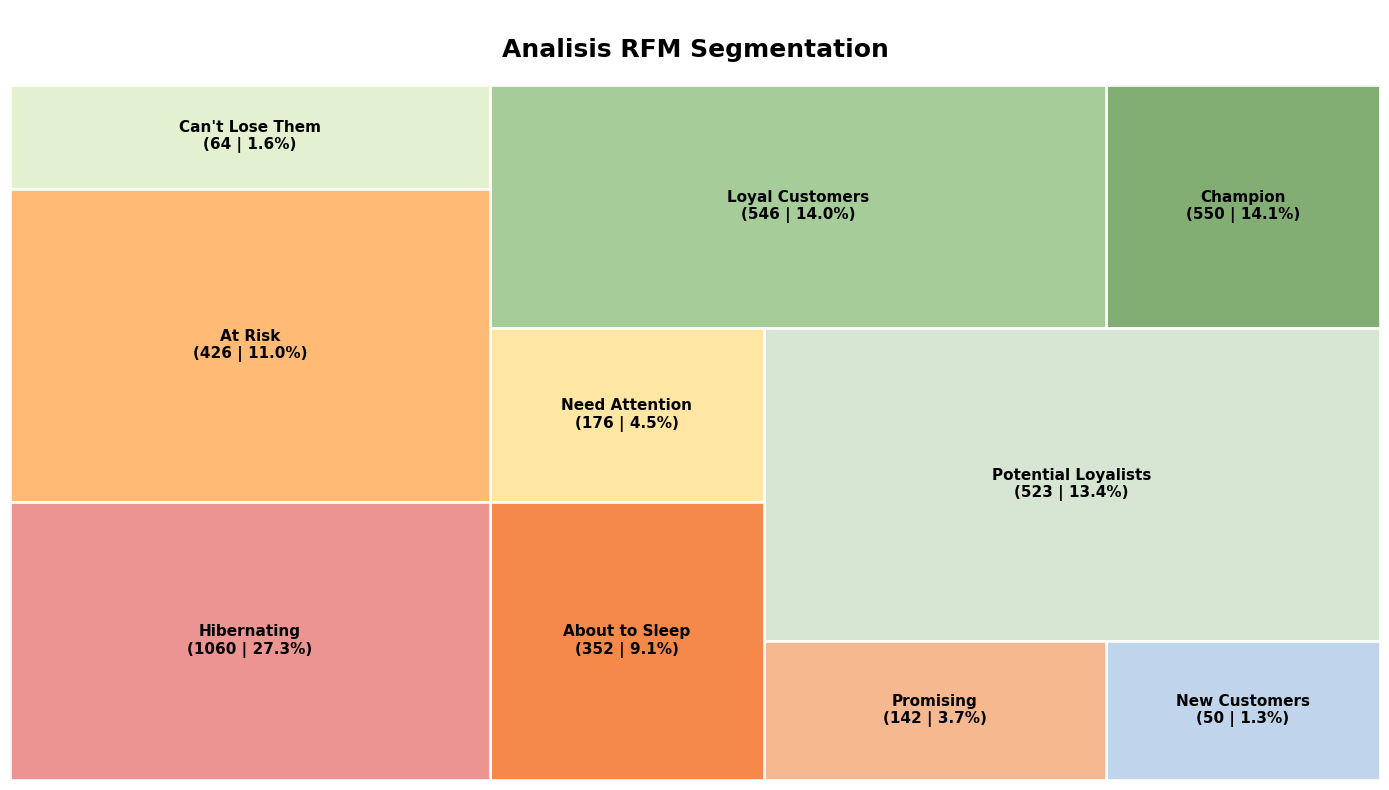

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. MENDUPLIKASI LAYOUT (Koordinat x, y, lebar, tinggi)
# Skala kanvas yang kita gunakan adalah 0 sampai 100 (persen)
# Koordinat ini saya ukur agar persis meniru gambar referensi Anda
layout = {
    '01-Champion':            {'x': 80, 'y': 65, 'w': 20, 'h': 35, 'color': '#76A564'},
    '02-Loyal Customers':     {'x': 35, 'y': 65, 'w': 45, 'h': 35, 'color': '#9DC78F'},
    '03-Potential Loyalists': {'x': 55, 'y': 20, 'w': 45, 'h': 45, 'color': '#D3E4CD'},
    "04-Can't Lose Them":     {'x':  0, 'y': 85, 'w': 35, 'h': 15, 'color': '#E2F0CB'},
    '05-Need Attention':      {'x': 35, 'y': 40, 'w': 20, 'h': 25, 'color': '#FFE599'},
    '06-New Customers':       {'x': 80, 'y':  0, 'w': 20, 'h': 20, 'color': '#B9D1EA'},
    '07-Promising':           {'x': 55, 'y':  0, 'w': 25, 'h': 20, 'color': '#F4B183'},
    '08-At Risk':             {'x':  0, 'y': 40, 'w': 35, 'h': 45, 'color': '#FFB366'},
    '09-About to Sleep':      {'x': 35, 'y':  0, 'w': 20, 'h': 40, 'color': '#F47C36'},
    '10-Hibernating':         {'x':  0, 'y':  0, 'w': 35, 'h': 40, 'color': '#EA8986'}
}

# Membuat kanvas berukuran proporsional
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# 2. MENGGAMBAR KOTAK & MEMASUKKAN DATA
for segment, box in layout.items():

    # Menarik jumlah dan persentase dari tabel 'summary' Anda
    # Try-Except digunakan agar kode tidak error jika nama kolom persentase sedikit berbeda
    try:
        count = int(summary.loc[segment, ('customer_id', 'nunique')])

        # Mengecek apakah pct_unique menggunakan multi-index atau index biasa
        if ('pct_unique', '') in summary.columns:
            pct = summary.loc[segment, ('pct_unique', '')]
        else:
            pct = summary.loc[segment, 'pct_unique']

    except Exception as e:
        count, pct = 0, 0.0 # Nilai jaga-jaga jika data kosong

    # Membersihkan nama segmen (misal: '01-Champion' -> 'Champion')
    segment_clean = segment.split('-', 1)[1] if '-' in segment else segment

    # Menggambar bentuk kotaknya
    rect = patches.Rectangle(
        (box['x'], box['y']), box['w'], box['h'],
        linewidth=2, edgecolor='white', facecolor=box['color'], alpha=0.9
    )
    ax.add_patch(rect)

    # Menentukan titik tengah kotak untuk menaruh teks
    center_x = box['x'] + (box['w'] / 2)
    center_y = box['y'] + (box['h'] / 2)

    # Memasukkan tulisan
    label = f"{segment_clean}\n({count} | {pct}%)"
    ax.text(center_x, center_y, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='black')

# 3. MERAPIKAN TAMPILAN
plt.title('\nAnalisis RFM Segmentation', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') # Mematikan garis koordinat X dan Y
plt.tight_layout()

# Tampilkan
plt.show()

## Kesimpulan

- Pengguna paling banyak berada pada segmen Hibernating (1060 atau 27.3%), Champion (550 atau 14.1%), dan Loyal Customers (546 atau 14.0%).

- Program khusus yang fokus pada urgensi bertransaksi untuk Loyal Customers (546 atau 14.0%) dapat dibuat untuk membuat mereka bertransaksi kembali dalam waktu dekat sehingga bisa naik ke segmen Champion.

- Program khusus yang fokus pada jumlah transaksi untuk Potential Loyalists (523 atau 13.4%) dapat dibuat untuk membuat mereka lebih sering bertransaksi sehingga bisa naik ke segmen Champion.

- Program khusus untuk Hibernating (1060 atau 27.3%) dapat dibuat untuk membuat mereka kembali bertransaksi walaupun belum begitu sering sehingga bisa naik ke segmen New Customers atau bahkan Potential Loyalists.